In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
tokenring_df = pl.read_csv("../results/tokenring-20260529-164437/raw-runs.csv")

In [30]:
sim4da_df = pl.read_csv("../results/sim4da-firework-20260607-132544/raw-runs.csv")

In [36]:
tokenring_df_distributed = pl.read_csv("../results/tokenring-distributed-20260611-165616/raw-runs.csv")

In [32]:
tokenring_df

runIndex,n,repetition,status,rounds,multicasts,minMs,avgMs,maxMs,durationSeconds,heapMbPerNode
i64,i64,i64,str,i64,i64,f64,f64,f64,f64,i64
0,2,1,"""ok""",5,4,0.167,6.936,32.625,0.391,4096
1,2,2,"""ok""",5,2,0.197,6.45,27.337,0.266,4096
2,2,3,"""ok""",7,3,0.195,4.983,28.624,0.25,4096
3,2,4,"""ok""",5,1,0.178,5.839,24.287,0.265,4096
4,2,5,"""ok""",3,0,0.226,8.469,24.866,0.265,4096
…,…,…,…,…,…,…,…,…,…,…
95,896,6,"""ok""",13,938,122.792,4308.236,34776.598,82.937,9
96,896,7,"""ok""",14,895,131.153,3811.55,34237.639,81.656,9
97,896,8,"""ok""",14,895,121.756,3763.698,34753.748,82.453,9


In [42]:
sim4da_df.filter((pl.col("n") == 2)).select(
    pl.col("rounds").mean().round(3).alias("mean_avgMs_n2")
)

mean_avgMs_n2
f64
4.4


In [16]:
tokenring_df = pl.read_csv("../results/tokenring-20260529-164437/raw-runs.csv")

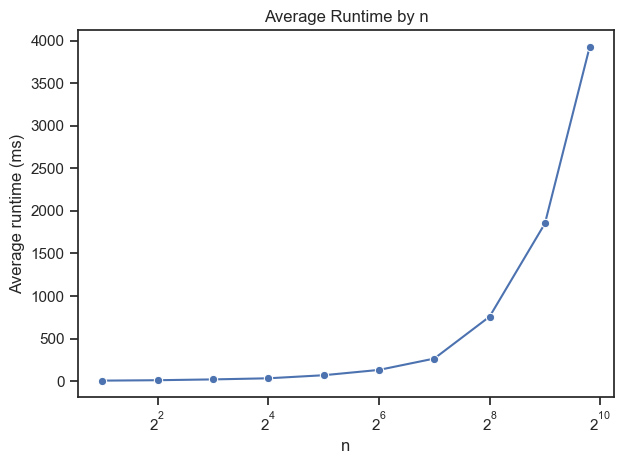

In [11]:
avg_by_n = (
    tokenring_df.group_by("n")
    .agg(pl.col("avgMs").mean().alias("averageRuntimeMs"))
    .sort("n")
)

sns.set_theme(style="ticks")

ax = sns.lineplot(
    data=avg_by_n,
    x="n",
    y="averageRuntimeMs",
    marker="o",
)

ax.set_xscale("log", base=2)
ax.set_xlabel("n")
ax.set_ylabel("Average runtime (ms)")
ax.set_title("Average Runtime by n")

plt.tight_layout()
plt.show()

In [5]:
sim4da_df = pl.read_csv("../results/sim4da-firework-20260607-132544/raw-runs.csv")

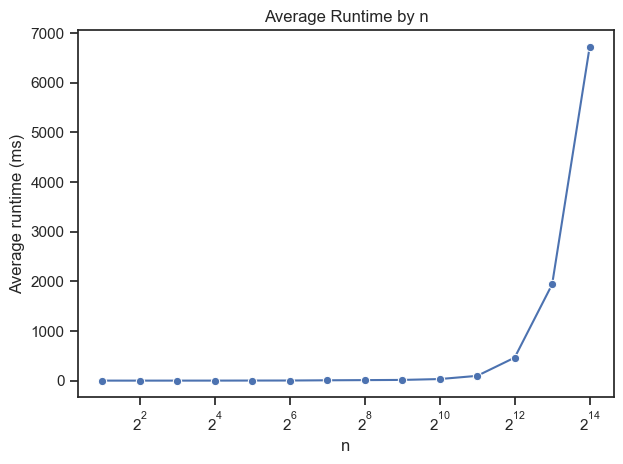

In [7]:
avg_by_n = (
    sim4da_df.group_by("n")
    .agg(pl.col("avgMs").mean().alias("averageRuntimeMs"))
    .sort("n")
)

sns.set_theme(style="ticks")

ax = sns.lineplot(
    data=avg_by_n,
    x="n",
    y="averageRuntimeMs",
    marker="o",
)

ax.set_xscale("log", base=2)
ax.set_xlabel("n")
ax.set_ylabel("Average runtime (ms)")
ax.set_title("Average Runtime by n")

plt.tight_layout()
plt.show()